In [14]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["HUGGINGFACEHUB_API_TOKEN"]=os.getenv("HUGGINGFACEHUB_API_TOKEN")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [15]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [16]:
#sample tool
from langchain_core.tools import tool

@tool
def weather(city: str) -> str:
    """Get the weather for a city."""
    return f"The weather in {city} is sunny."



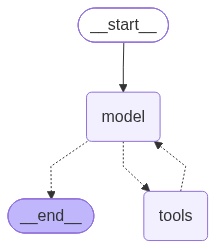

In [17]:
from langchain.agents import create_agent
agent=create_agent(
    model=llm,
    tools=[weather],
    system_prompt="you are helpful assitant"
)
agent

In [18]:
agent.invoke({"messages":[{"role":"user","content":"what is the weather like in New York?"}]})

{'messages': [HumanMessage(content='what is the weather like in New York?', additional_kwargs={}, response_metadata={}, id='75f66044-9216-444d-af20-7a6e656f264f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is the weather like in New York?" We need to fetch weather using the provided function. Use function call.', 'tool_calls': [{'id': 'fc_664b9217-95a9-4453-985e-6e35967e2f90', 'function': {'arguments': '{"city":"New York"}', 'name': 'weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 137, 'total_tokens': 193, 'completion_time': 0.117116801, 'completion_tokens_details': {'reasoning_tokens': 29}, 'prompt_time': 0.005389188, 'prompt_tokens_details': None, 'queue_time': 0.348156037, 'total_time': 0.122505989}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_fe269835c7', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'},

In [19]:
agent.invoke({'messages':"what is the weather in New york"})

{'messages': [HumanMessage(content='what is the weather in New york', additional_kwargs={}, response_metadata={}, id='621960b8-1c4c-4cb9-aefa-48f15fdec697'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is the weather in New york". We need to fetch weather using the function. Use function call.', 'tool_calls': [{'id': 'fc_a56ec934-6e3c-4696-9147-a30b341e5e09', 'function': {'arguments': '{"city":"New York"}', 'name': 'weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 135, 'total_tokens': 189, 'completion_time': 0.112170049, 'completion_tokens_details': {'reasoning_tokens': 27}, 'prompt_time': 0.005259864, 'prompt_tokens_details': None, 'queue_time': 0.407488614, 'total_time': 0.117429913}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_803c0ba83d', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0e1b

#Streaming and batch

In [20]:
from langchain_groq import ChatGroq
model=ChatGroq(model="qwen/qwen3.8-27b")


In [21]:
response = model.invoke("Why do parrots have colorful feathers?")
print(response.content)

The vibrant colors of parrots are the result of **evolutionary pressures** and **biological mechanisms** that serve several critical functions in their survival and reproduction. Here’s a detailed breakdown of why parrots have colorful feathers:

### 1. Sexual Selection and Mate Attraction
One of the primary reasons for bright plumage is **sexual selection**. In many parrot species, males display vivid colors to attract females.
- **Health Indicator**: Bright, well-maintained feathers often signal a healthy, genetically fit individual with access to good nutrition.
- **Courtship Displays**: Parrots use their colors in elaborate courtship dances and displays. For example, the Scarlet Macaw’s striking red, yellow, and blue feathers make it highly visible to potential mates in the dense canopy.

### 2. Camouflage and Mimicry
Contrary to intuition, bright colors can also provide camouflage in their natural habitats:
- **Rainforest Environment**: Parrots live in tropical rainforests filled 

In [26]:
for chunk in model.stream("Why do parrots have colorful feathers?"):
    print(chunk.text,flush=True)


The
 vibrant
 colors
 of
 par
rots
 are
 the
 result
 of
 millions
 of
 years
 of
 evolution
,
 driven
 primarily
 by
 **
natural
 selection
**
 and
 **
sexual
 selection
**.
 Their
 plum
age
 serves
 several
 critical
 biological
 functions
:



###
 
1
.
 Sexual
 Selection
 and
 M
ating


One
 of
 the
 most
 significant
 reasons
 for
 bright
 colors
 is
 to
 attract
 mates
.


-
 **
Signal
 of
 Health
**:
 Bright
,
 sym
metrical
,
 and
 vivid
 feathers
 often
 indicate
 that
 a
 bird
 is
 healthy
,
 well
-n
our
ished
,
 and
 free
 from
 parasites
.
 In
 many
 species
,
 only
 the
 health
iest
 individuals
 can
 produce
 the
 most
 intense
 colors
.


-
 **
Species
 Recognition
**:
 Specific
 color
 patterns
 help
 par
rots
 identify
 members
 of
 their
 own
 species
 for
 mating
,
 ensuring
 genetic
 compatibility
.



###
 
2
.
 Cam
ouflage
 in
 Tropical
 Habit
ats


Par
rots
 mostly
 live
 in
 tropical
 rain
fore
sts
,
 which
 are
 rich
 in
 bright
 red
s
,
 oranges
,
 yell
ows
,
